In [7]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/rsi-data-15-dec-2025/Python Analysis_All in one_RSI Data.xlsx


## Loading dataset & Cleaning

In [8]:
import pandas as pd

# Load the updated Excel file
file_path = "/kaggle/input/rsi-data-15-dec-2025/Python Analysis_All in one_RSI Data.xlsx"

df = pd.read_excel(file_path)


print("Shape of data:", df.shape)
print("\nColumn names:\n")
for i, col in enumerate(df.columns):
    print(i, col)

# Preview first few rows
#df.head()


Shape of data: (23135, 31)

Column names:

0 Sl No
1 Name of Surveyor
2 Weather
3 Dae of Survey
4 Day of Survey
5 Survey Point
6 Direction
7 Survey Time
8 Origin_Place
9 Origin_Thana/Upazila
10 Origin_Location
11 Origin_Zilla
12 Origin_TAZ
13 Destination_Place
14 Destination_Thana/Upazila
15 Destination_Location
16 Destination_Zilla
17 Destination_TAZ
18 Age
19 Gender
20 Vehicle Type
21 Trip Frequency
22 Trip Purpose
23 Vehicle Capacity
24 Vehicle Occupancy(Including Driver)
25 Trip Length
26 Trip Cost
27 Unnamed: 27
28 Unnamed: 28
29 Unnamed: 29
30 Unnamed: 30


In [12]:
df["Origin_Location"].head()

0               KALSHI Mor PALLABI 
1                MIRPUR 11 PALLABI 
2              MIRPUR DOHS PALLABI 
3                 MIRPUR 6 RUPNAGAR
4    Manikdi Bazar DHAKA CANTONMENT
Name: Origin_Location, dtype: object

### Replacing Survey Points With their Actual Names

In [13]:
id_to_location = {
    "MC-01": "New Airport Road",
    "MC-02": "Baunia Road",
    # "MC-03": already original → skip
    "MC-5": "Balughat Bazar Road",
    "MC-07": "Jasimuddin Baunia Road",
    "MC-8": "Matikata Road",
    "MC-09": "Sonargaon Jonopath",
    "MC-10": "2 No. Bridge"
    # "IC-01": already original → skip
}

df["Survey Point"] = df["Survey Point"].replace(id_to_location)
df["Survey Point"].value_counts() 
#df["Survey Point"].unique()

Survey Point
New Airport Road             3541
ECB CHATTAR                  3100
Sonargaon Jonopath           3060
2 No. Bridge                 2661
MIRPUR DOHS 2 NUMBER GATE    2496
Matikata Road                2479
Balughat Bazar Road          2028
Jasimuddin Baunia Road       1979
Baunia Road                  1791
Name: count, dtype: int64

### Replacing Vehicle Type With their Actual Names

In [14]:
vehicle_type_map = {
    1: "Bicycle",
    2: "Rickshaw",
    3: "Rickshaw Van",
    4: "School Van",
    5: "Rickshaw Van (Push Cart)",
    6: "Motor Cycle",
    7: "CNG / Mishuk",
    8: "Auto",
    9: "Car / SUV",
    10: "Taxi",
    11: "Microbus",
    12: "Jeep / Utility Vehicle",
    13: "Tempo / Laguna / Maxi",
    14: "Minibus",
    15: "Large Bus – Single Decker",
    16: "Large Bus – Double Decker",
    17: "AC Bus",
    18: "Staff Bus",
    19: "School / College / University Bus",
    20: "Small Open Truck / Small Van / Pickup",
    21: "Medium Truck / Truck 2 Axle",
    22: "Large Truck / 3 Axle Truck",
    23: "Container Trailer",
    24: "Tanker / Tank Lorry",
    25: "Others"
}

df["Vehicle Type Name"] = df["Vehicle Type"].map(vehicle_type_map)
df[["Vehicle Type", "Vehicle Type Name"]].head(10)


,Vehicle Type,Vehicle Type Name
0,9,Car / SUV
1,15,Large Bus – Single Decker
2,9,Car / SUV
3,9,Car / SUV
4,7,CNG / Mishuk
5,15,Large Bus – Single Decker
6,15,Large Bus – Single Decker
7,9,Car / SUV
8,6,Motor Cycle
9,7,CNG / Mishuk


In [15]:
# Replacing 'PERSONAL WORK' with 9 in Trip Purpose column
df["Trip Purpose"] = df["Trip Purpose"].replace("PERSONAL WORK", 9)

# Convert Trip Purpose to numeric (important for analysis)
df["Trip Purpose"] = pd.to_numeric(df["Trip Purpose"], errors="coerce")

# Checking unique values to confirm replacement
print("Unique Trip Purpose values after replacement:")
print(sorted(df["Trip Purpose"].dropna().unique()))

Unique Trip Purpose values after replacement:
[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0]


### Replacing Trip Purposee With their Actual Names

In [16]:
trip_purpose_map = {
    1: "Home",
    2: "Work (Business)",
    3: "Work (Commuting)",
    4: "Education",
    5: "Leisure",
    6: "Shopping",
    7: "Terminal",
    8: "Medical",
    9: "Personal Work"
}
df["Trip Purpose Name"] = df["Trip Purpose"].map(trip_purpose_map)
df[["Trip Purpose", "Trip Purpose Name"]].head(10)


/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,Trip Purpose,Trip Purpose Name
0,NaN,NaN
1,7.0,Terminal
2,1.0,Home
3,6.0,Shopping
4,1.0,Home
5,7.0,Terminal
6,7.0,Terminal
7,3.0,Work (Commuting)
8,8.0,Medical
9,2.0,Work (Business)


## Visualization of Vehicle Type

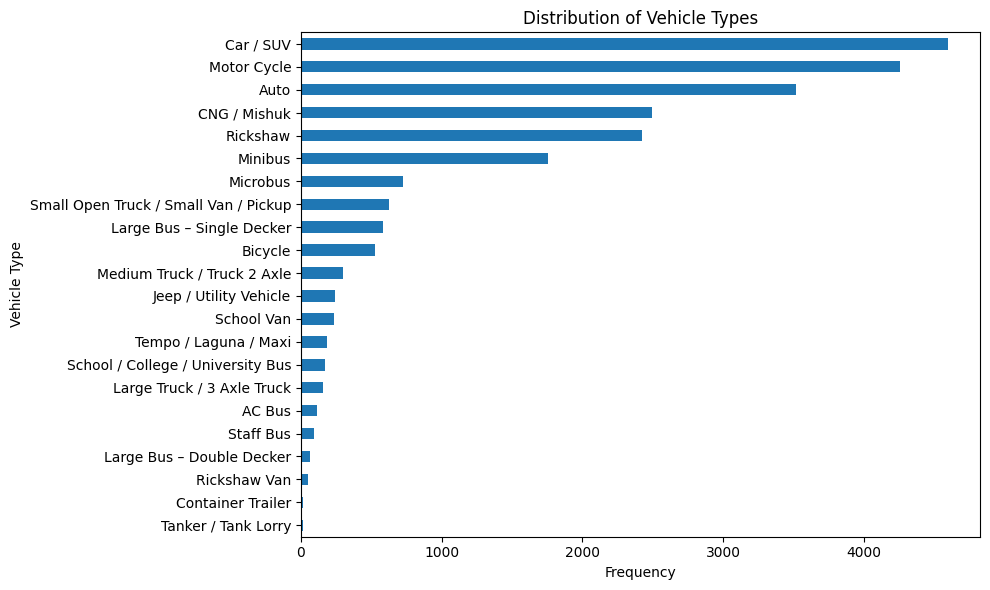

In [17]:
import matplotlib.pyplot as plt
vehicle_name_counts = df["Vehicle Type Name"].value_counts()

plt.figure(figsize=(10,6))
vehicle_name_counts.sort_values().plot(kind="barh")

plt.title("Distribution of Vehicle Types")
plt.xlabel("Frequency")
plt.ylabel("Vehicle Type")
plt.tight_layout()
plt.show() 

In [18]:
vehicle_counts = df["Vehicle Type Name"].value_counts()

vehicle_summary = vehicle_counts.reset_index()
vehicle_summary.columns = ["Vehicle Type", "Frequency"]

vehicle_summary["Percentage (%)"] = (
    vehicle_summary["Frequency"] / vehicle_summary["Frequency"].sum() * 100
).round(2)

vehicle_summary

,Vehicle Type,Frequency,Percentage (%)
0,Car / SUV,4595,19.86
1,Motor Cycle,4259,18.41
2,Auto,3514,15.19
3,CNG / Mishuk,2493,10.78
4,Rickshaw,2426,10.49
5,Minibus,1758,7.60
6,Microbus,724,3.13
7,Small Open Truck / Small Van / Pickup,628,2.71
8,Large Bus – Single Decker,585,2.53
9,Bicycle,523,2.26


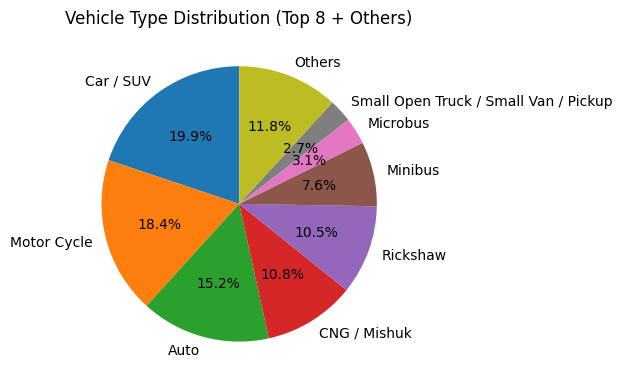

In [19]:
top_n = 8
top_vehicles = vehicle_name_counts.head(top_n)
others = vehicle_name_counts.iloc[top_n:].sum()

pie_data = top_vehicles.copy()
pie_data["Others"] = others

plt.figure(figsize=(6,6))
plt.pie(
    pie_data.values,
    labels=pie_data.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Vehicle Type Distribution (Top 8 + Others)")
plt.tight_layout()

# Saving figure
plt.savefig(
    "Vehicle_Type_Distribution_Top8_Others.png",
    dpi=300,           
    bbox_inches="tight"
)

plt.show()


### 

## Visualization of Trip Purpose

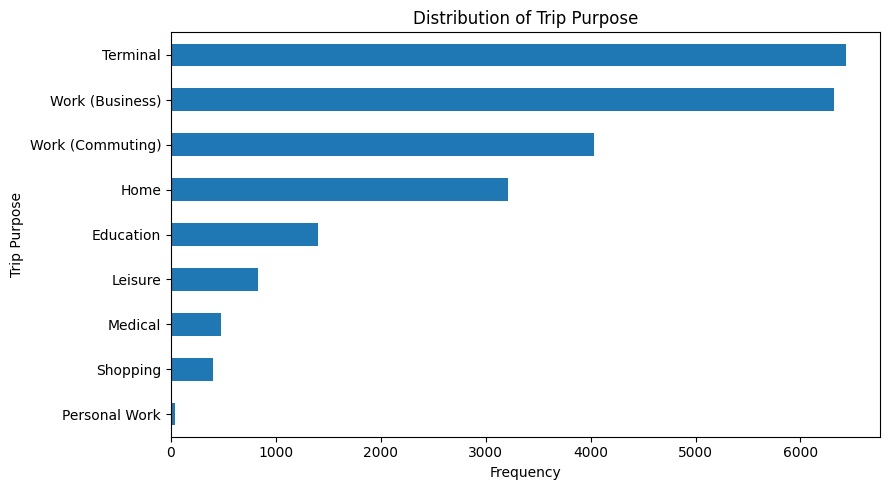

In [20]:
import matplotlib.pyplot as plt

trip_name_counts = df["Trip Purpose Name"].value_counts()

plt.figure(figsize=(9,5))
trip_name_counts.sort_values().plot(kind="barh")

plt.title("Distribution of Trip Purpose")
plt.xlabel("Frequency")
plt.ylabel("Trip Purpose")
plt.tight_layout()


plt.savefig(
    "Trip_Purpose_Distribution_Bar.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [21]:
trip_summary = trip_name_counts.reset_index()
trip_summary.columns = ["Trip Purpose", "Frequency"]

trip_summary["Percentage (%)"] = (
    trip_summary["Frequency"] / trip_summary["Frequency"].sum() * 100
).round(2)

trip_summary

,Trip Purpose,Frequency,Percentage (%)
0,Terminal,6436,27.82
1,Work (Business),6315,27.30
2,Work (Commuting),4032,17.43
3,Home,3211,13.88
4,Education,1400,6.05
5,Leisure,833,3.60
6,Medical,475,2.05
7,Shopping,397,1.72
8,Personal Work,35,0.15


## Age wise Travel Behavior Analysis

- Which age groups prefer which vehicle types

- How mobility behavior changes with age

- Demand forecasting

- Targeted transport policy

In [22]:
bins = [0, 18, 25, 35, 45, 60, 100]
labels = ["<18", "18–25", "26–35", "36–45", "46–60", "60+"]

df["Age Group"] = pd.cut(df["Age"], bins=bins, labels=labels)

#pd.crosstab(df["Age Group"], df["Vehicle Type Name"])


age_vehicle_pct = (
    pd.crosstab(
        df["Age Group"],
        df["Vehicle Type Name"],
        normalize="index"
    ) * 100
).round(2)
age_vehicle_pct

Vehicle Type Name,AC Bus,Auto,Bicycle,CNG / Mishuk,Car / SUV,Container Trailer,Jeep / Utility Vehicle,Large Bus – Double Decker,Large Bus – Single Decker,Large Truck / 3 Axle Truck,...,Minibus,Motor Cycle,Rickshaw,Rickshaw Van,School / College / University Bus,School Van,Small Open Truck / Small Van / Pickup,Staff Bus,Tanker / Tank Lorry,Tempo / Laguna / Maxi
Age Group,,,,,,,,,,,,,,,,,,,,,
<18,0.00,53.69,10.74,5.37,6.04,0.00,0.67,0.67,0.67,0.00,...,0.67,5.37,11.41,0.67,1.34,0.67,0.00,0.00,0.00,1.34
18–25,0.29,25.49,3.96,7.18,12.47,0.05,0.58,0.24,1.55,0.39,...,6.02,20.17,13.75,0.22,0.51,1.06,2.05,0.12,0.07,0.46
26–35,0.55,13.22,2.06,10.19,22.32,0.04,0.98,0.22,2.27,0.58,...,6.97,19.83,10.35,0.26,0.60,0.98,2.99,0.38,0.08,0.80
36–45,0.55,11.24,1.41,14.05,20.58,0.10,1.47,0.42,3.57,0.94,...,9.23,15.86,8.64,0.13,0.97,1.06,2.81,0.67,0.02,1.00
46–60,0.48,13.71,1.67,12.10,20.32,0.06,1.01,0.36,3.22,1.37,...,10.37,14.78,9.95,0.00,1.13,1.19,2.44,0.24,0.00,0.83
60+,1.22,9.76,2.44,15.85,23.17,0.00,0.00,0.00,1.22,0.00,...,9.76,20.73,7.32,0.00,1.22,0.00,2.44,0.00,0.00,1.22


In [24]:
output_file = "AgeGroup_vs_VehicleType_Percentage.xlsx"
age_vehicle_pct.to_excel(output_file)

output_file


[]

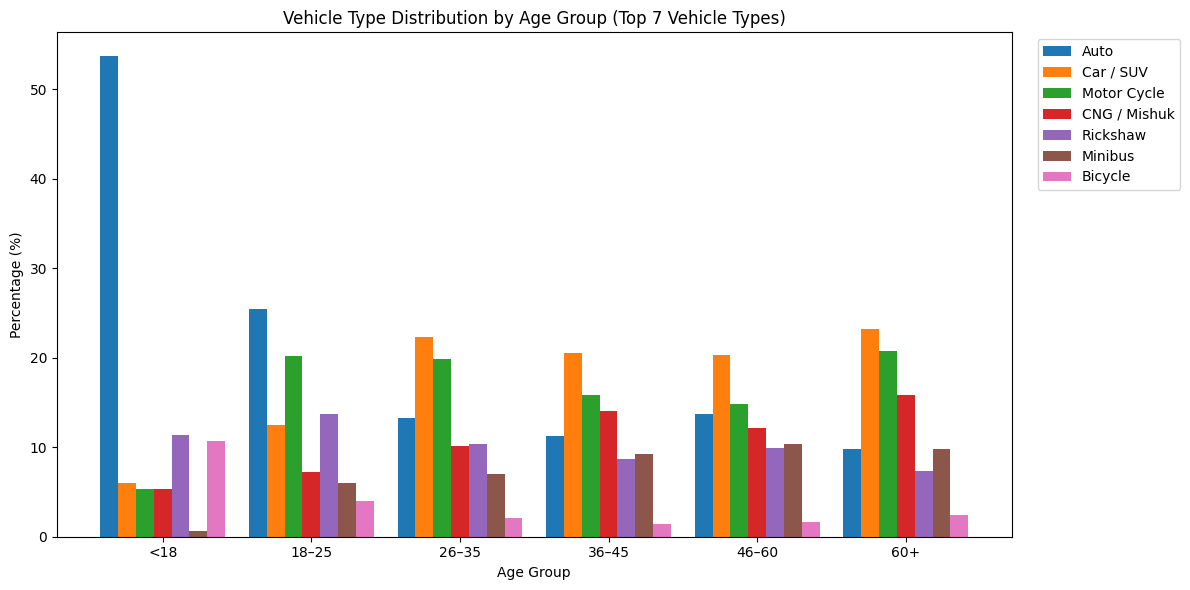

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# Using percentage table
age_vehicle_pct = age_vehicle_pct.copy()  

# Picking top N vehicle types by overall share (across all age groups)
top_n = 7
top_vehicle_types = age_vehicle_pct.mean(axis=0).sort_values(ascending=False).head(top_n).index

plot_df = age_vehicle_pct[top_vehicle_types]

# Grouped bar chart
age_groups = plot_df.index.astype(str)
vehicle_types = plot_df.columns.astype(str)

x = np.arange(len(age_groups))          
bar_width = 0.12                        

plt.figure(figsize=(12,6))

for i, vt in enumerate(vehicle_types):
    plt.bar(x + i*bar_width, plot_df[vt].values, width=bar_width, label=vt)

plt.xticks(x + (len(vehicle_types)-1)*bar_width/2, age_groups)
plt.xlabel("Age Group")
plt.ylabel("Percentage (%)")
plt.title(f"Vehicle Type Distribution by Age Group (Top {top_n} Vehicle Types)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

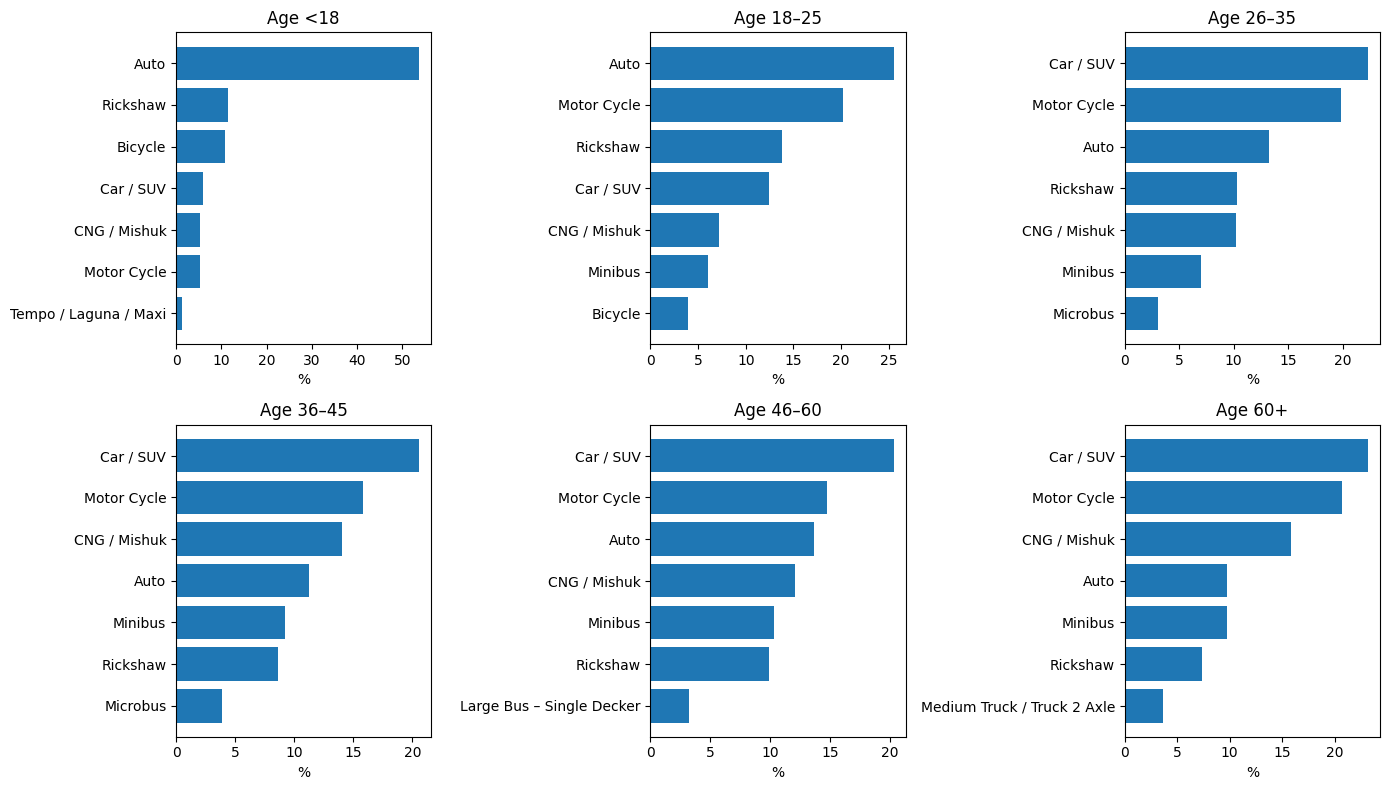

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(14,8))
axes = axes.flatten()

top_n = 7

for ax, age in zip(axes, age_vehicle_pct.index):
    data = (
        age_vehicle_pct.loc[age]
        .sort_values(ascending=False)
        .head(top_n)
    )

    ax.barh(data.index, data.values)
    ax.invert_yaxis()
    ax.set_title(f"Age {age}")
    ax.set_xlabel("%")

plt.tight_layout()
plt.show() 


In [ ]:
plt.savefig("AgeGroup_vs_VehicleType_Faceted_Bar.png", dpi=300, bbox_inches="tight")

### “Which vehicle type has the highest share in each age group?”

In [27]:
max_vehicle_by_age = age_vehicle_pct.idxmax(axis=1)
max_value_by_age = age_vehicle_pct.max(axis=1)

result_max = pd.DataFrame({
    "Dominant Vehicle Type": max_vehicle_by_age,
    "Percentage (%)": max_value_by_age.round(2)
})

result_max

,Dominant Vehicle Type,Percentage (%)
Age Group,,
<18,Auto,53.69
18–25,Auto,25.49
26–35,Car / SUV,22.32
36–45,Car / SUV,20.58
46–60,Car / SUV,20.32
60+,Car / SUV,23.17


## Survey point wise Mode Analysis

In [28]:
survey_vehicle_pct = (
    pd.crosstab(
        df["Survey Point"],
        df["Vehicle Type Name"],
        normalize="index"
    ) * 100
).round(2)

survey_point_tables = {}

for sp in survey_vehicle_pct.index:
    temp = (
        survey_vehicle_pct.loc[sp]
        .sort_values(ascending=False)
        .reset_index()
    )
    temp.columns = ["Vehicle Type", "Percentage (%)"]
    survey_point_tables[sp] = temp

with pd.ExcelWriter("SurveyPoint_VehicleType_Distribution.xlsx",
                    engine="openpyxl") as writer:
    for sp, table in survey_point_tables.items():
        sheet_name = str(sp)[:31]  # Excel sheet name limit
        table.to_excel(writer, sheet_name=sheet_name, index=False)



### Visualization

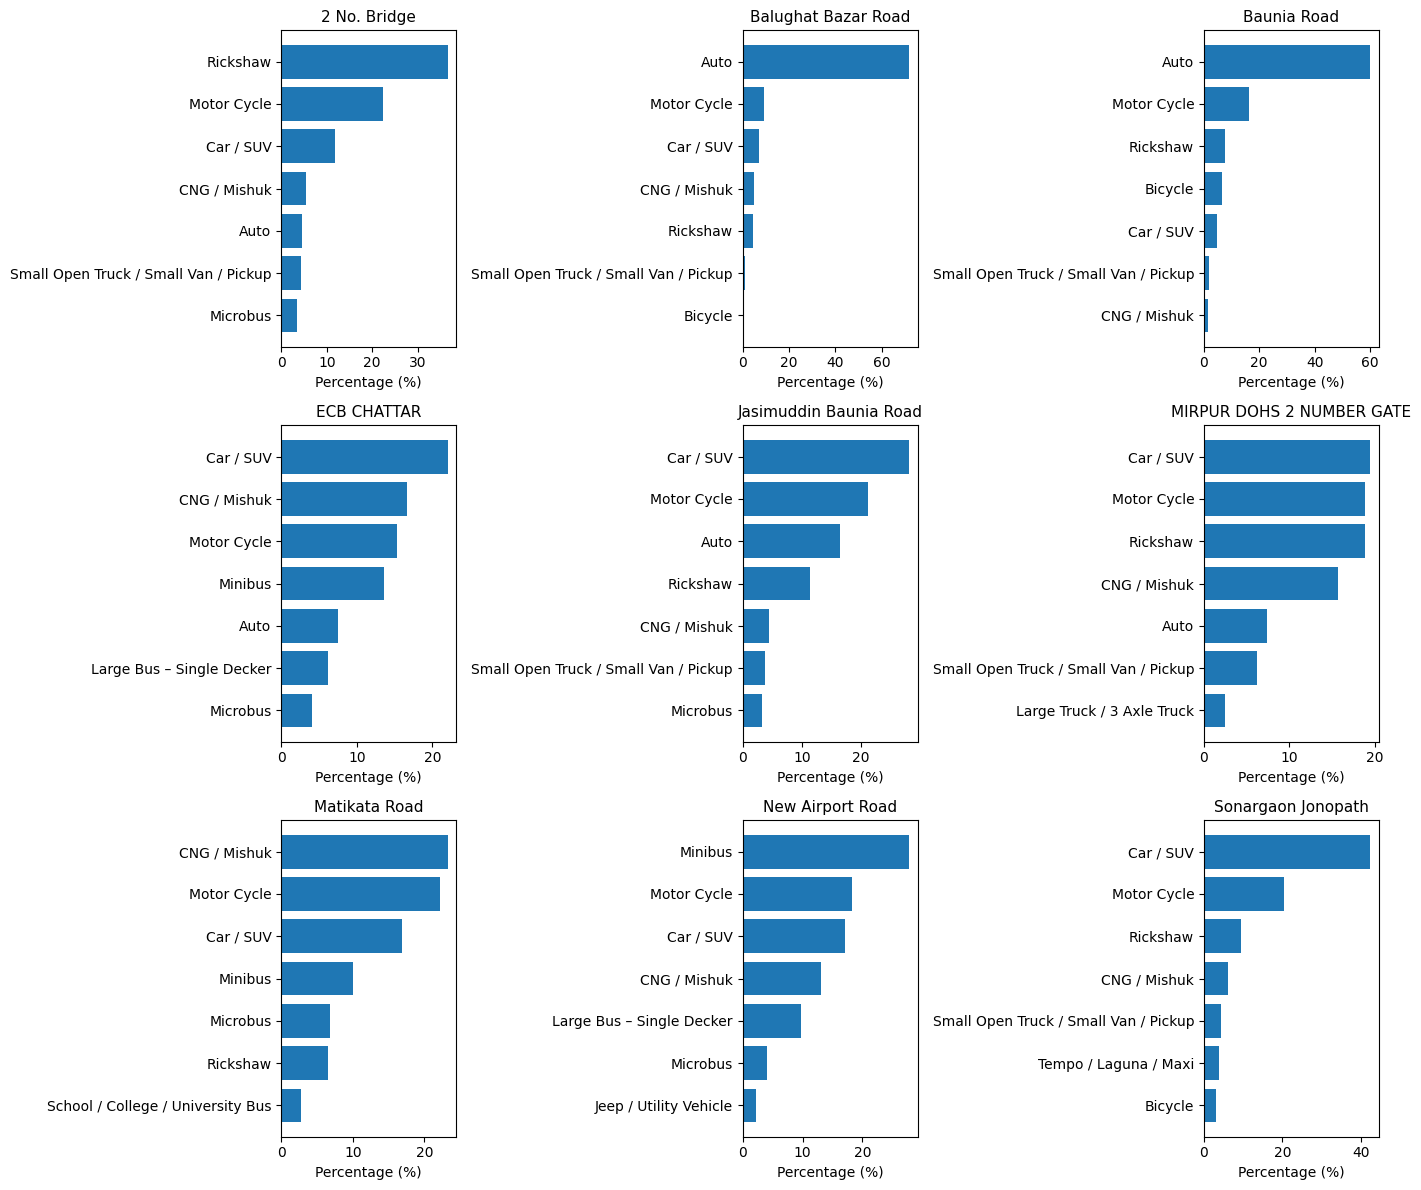

In [29]:
import matplotlib.pyplot as plt
import math

top_n = 7  

survey_points = survey_vehicle_pct.index.tolist()
n_points = len(survey_points)

# layout: 3 plots per row
n_cols = 3
n_rows = math.ceil(n_points / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten()

for ax, sp in zip(axes, survey_points):
    data = (
        survey_vehicle_pct.loc[sp]
        .sort_values(ascending=False)
        .head(top_n)
    )

    ax.barh(data.index, data.values)
    ax.invert_yaxis()
    ax.set_title(sp, fontsize=11)
    ax.set_xlabel("Percentage (%)")


for i in range(len(survey_points), len(axes)):
    axes[i].axis("off")

plt.tight_layout()


plt.savefig(
    "SurveyPoint_vs_VehicleType_Top7.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


### Dominant Type Vehicle of each survey Point

In [30]:
dominant_vehicle_by_point = pd.DataFrame({
    "Dominant Vehicle Type": survey_vehicle_pct.idxmax(axis=1),
    "Percentage (%)": survey_vehicle_pct.max(axis=1).round(2)
})

dominant_vehicle_by_point 

,Dominant Vehicle Type,Percentage (%)
Survey Point,,
2 No. Bridge,Rickshaw,36.68
Balughat Bazar Road,Auto,71.75
Baunia Road,Auto,60.19
ECB CHATTAR,Car / SUV,22.06
Jasimuddin Baunia Road,Car / SUV,28.09
MIRPUR DOHS 2 NUMBER GATE,Car / SUV,19.51
Matikata Road,CNG / Mishuk,23.28
New Airport Road,Minibus,27.82
Sonargaon Jonopath,Car / SUV,42.45


## Mode Wise Trip & Cost Analysis

### Min, Max, Avg Cost per Km

In [31]:
df["Cost_per_km"] = df["Trip Cost"] / df["Trip Length"]

vehicle_cost_stats = (
    df.groupby("Vehicle Type Name")["Cost_per_km"]
      .agg(
          Min_Cost_per_km="min",
          Avg_Cost_per_km="mean",
          Max_Cost_per_km="max"
      )
      .round(2)
      .sort_values("Avg_Cost_per_km", ascending=False)
)

vehicle_cost_stats


,Min_Cost_per_km,Avg_Cost_per_km,Max_Cost_per_km
Vehicle Type Name,,,
Container Trailer,8.33,22.80,36.11
Large Truck / 3 Axle Truck,2.00,20.50,200.00
Tanker / Tank Lorry,13.89,18.19,25.00
Medium Truck / Truck 2 Axle,3.33,17.31,83.33
School / College / University Bus,2.78,15.53,60.00
Small Open Truck / Small Van / Pickup,0.33,13.51,250.00
Staff Bus,3.12,11.17,25.00
School Van,1.67,11.10,25.00
Microbus,0.36,8.61,73.33


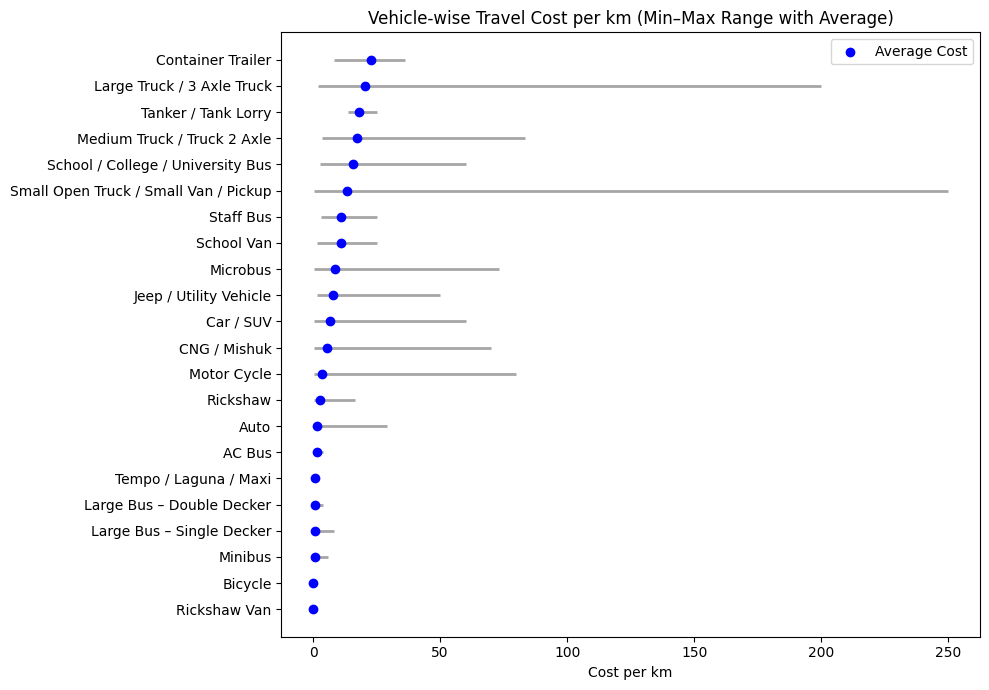

In [32]:
df["Cost_per_km"] = df["Trip Cost"] / df["Trip Length"]

vehicle_cost_stats = (
    df.groupby("Vehicle Type Name")["Cost_per_km"]
      .agg(
          Min_Cost_per_km="min",
          Avg_Cost_per_km="mean",
          Max_Cost_per_km="max"
      )
      .round(2)
      .sort_values("Avg_Cost_per_km", ascending=True)
)

# Resetting index for plotting
df_plot = vehicle_cost_stats.reset_index()

plt.figure(figsize=(10, 7))


plt.hlines(
    y=df_plot["Vehicle Type Name"],
    xmin=df_plot["Min_Cost_per_km"],
    xmax=df_plot["Max_Cost_per_km"],
    color="gray",
    alpha=0.7,
    linewidth=2
)

# Average cost markers
plt.scatter(
    df_plot["Avg_Cost_per_km"],
    df_plot["Vehicle Type Name"],
    color="blue",
    zorder=3,
    label="Average Cost"
)

plt.xlabel("Cost per km")
plt.title("Vehicle-wise Travel Cost per km (Min–Max Range with Average)")
plt.legend()
plt.tight_layout()

# Save figures
plt.savefig("Vehicle_Wise_Cost_per_km_MinMax_Average.png", dpi=300, bbox_inches="tight")
plt.savefig("Vehicle_Wise_Cost_per_km_MinMax_Average.pdf", dpi=300, bbox_inches="tight")

plt.show()


### Avg Trip Length

In [33]:
vehicle_trip_length_stats = (
    df.groupby("Vehicle Type Name")["Trip Length"]
      .agg(
          Min_Trip_Length_km="min",
          Avg_Trip_Length_km="mean",
          Max_Trip_Length_km="max"
      )
      .round(2)
      .sort_values("Avg_Trip_Length_km", ascending=False)
)

vehicle_trip_length_stats

,Min_Trip_Length_km,Avg_Trip_Length_km,Max_Trip_Length_km
Vehicle Type Name,,,
Container Trailer,20,213.08,720
Large Bus – Single Decker,10,199.14,560
AC Bus,15,192.13,450
Medium Truck / Truck 2 Axle,10,153.54,850
Tanker / Tank Lorry,120,151.15,220
Minibus,10,124.20,260
Large Truck / 3 Axle Truck,10,123.81,720
Large Bus – Double Decker,10,115.71,560
Jeep / Utility Vehicle,10,109.69,650


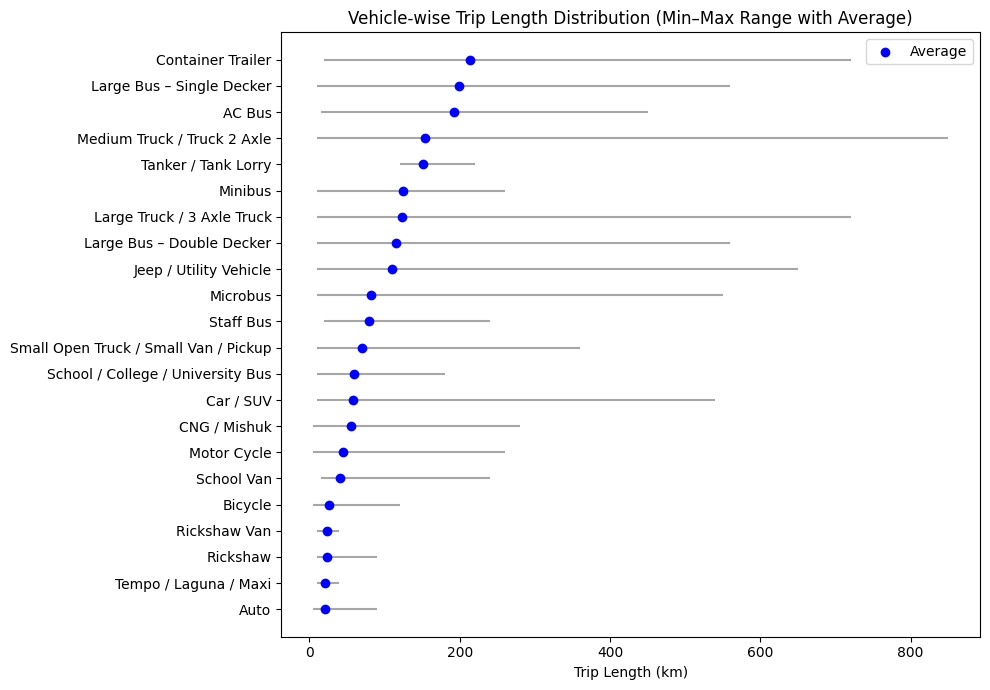

In [34]:
vehicle_trip_length_df = vehicle_trip_length_stats.reset_index()
vehicle_trip_length_df.columns = [
    "Vehicle Type",
    "Minimum Trip Length (km)",
    "Average Trip Length (km)",
    "Maximum Trip Length (km)"
]

vehicle_trip_length_df

df_plot = vehicle_trip_length_df.sort_values(
    "Average Trip Length (km)", ascending=True
)

plt.figure(figsize=(10,7))


plt.hlines(
    y=df_plot["Vehicle Type"],
    xmin=df_plot["Minimum Trip Length (km)"],
    xmax=df_plot["Maximum Trip Length (km)"],
    color="gray",
    alpha=0.7
)


plt.scatter(
    df_plot["Average Trip Length (km)"],
    df_plot["Vehicle Type"],
    color="blue",
    zorder=3,
    label="Average"
)

plt.xlabel("Trip Length (km)")
plt.title("Vehicle-wise Trip Length Distribution (Min–Max Range with Average)")
plt.legend()
plt.tight_layout()


plt.savefig(
    "Vehicle_Wise_Trip_km_MinMax_Average.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


## Vehicle Occupancy

In [36]:
vehicle_Occupancy_stats = (
    df.groupby("Vehicle Type Name")["Vehicle Occupancy(Including Driver)"]
      .agg(
          Min_Occupancy="min",
          Avg_Occupancy="mean",
          Max_Occupancy="max"
      )
      .round(2)
      .sort_values("Avg_Occupancy", ascending=False)
)

vehicle_Occupancy_stats

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,Min_Occupancy,Avg_Occupancy,Max_Occupancy
Vehicle Type Name,,,
Large Bus – Double Decker,8.0,39.32,72.0
Large Bus – Single Decker,8.0,30.17,45.0
AC Bus,5.0,28.57,36.0
Minibus,10.0,28.16,46.0
Staff Bus,3.0,15.62,40.0
School / College / University Bus,5.0,15.61,31.0
Tempo / Laguna / Maxi,4.0,10.25,15.0
Rickshaw Van,3.0,5.60,7.0
Microbus,1.0,5.14,16.0


In [39]:
vehicle_Occupancy_stats.to_excel(
    "vehicle_occupancy_stats.xlsx",
    sheet_name="Occupancy_Stats"
)


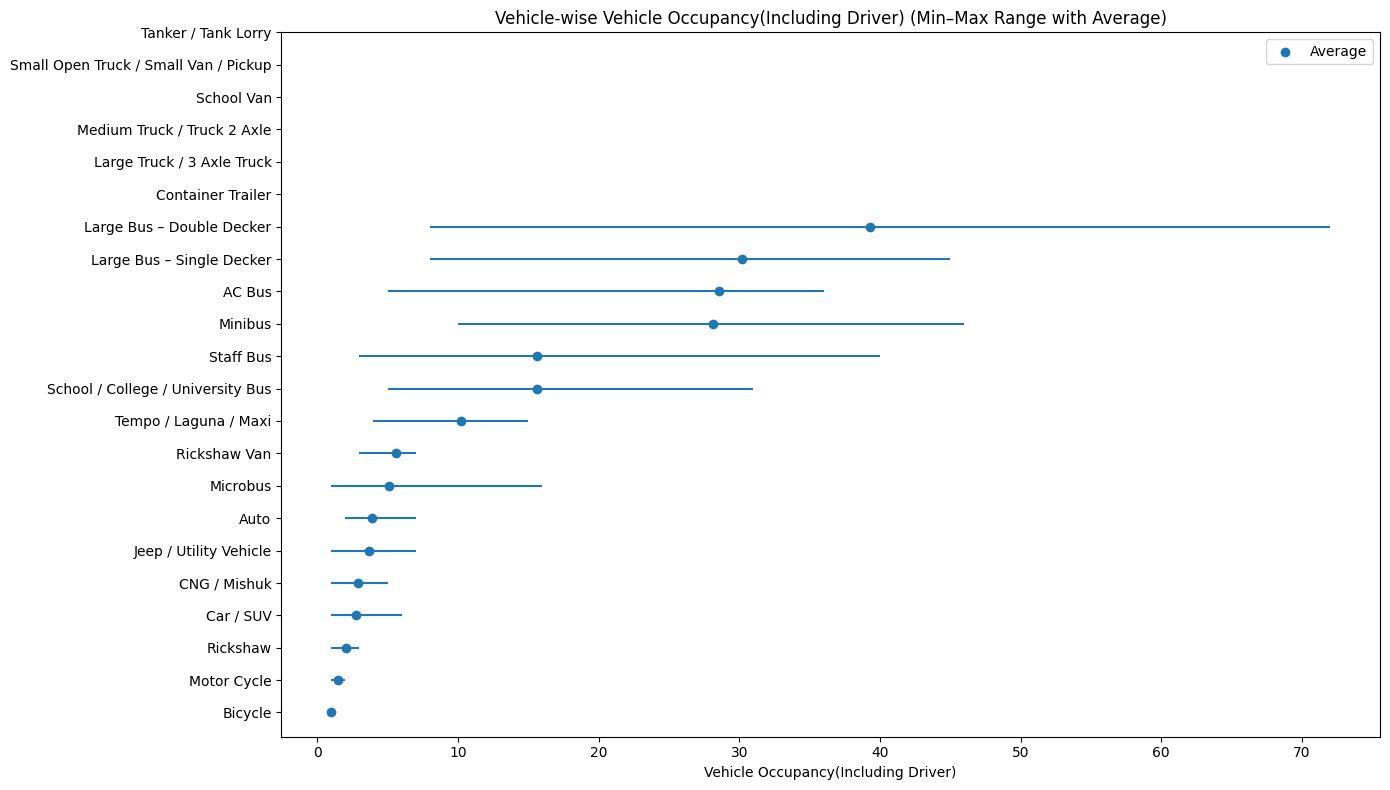

In [40]:
import pandas as pd
import matplotlib.pyplot as plt


stats = (
    df.groupby("Vehicle Type Name")["Vehicle Occupancy(Including Driver)"]
      .agg(Min="min", Avg="mean", Max="max")
      .reset_index()
)

stats = stats.sort_values("Avg", ascending=True)

plt.figure(figsize=(14, 8))

y = range(len(stats))

plt.hlines(y=y, xmin=stats["Min"], xmax=stats["Max"])

plt.scatter(stats["Avg"], y, label="Average")

plt.yticks(y, stats["Vehicle Type Name"])

plt.xlabel("Vehicle Occupancy(Including Driver)")
plt.title("Vehicle-wise Vehicle Occupancy(Including Driver) (Min–Max Range with Average)")
plt.legend()
plt.tight_layout()
plt.savefig(
    "Vehicle_Occupancy_MinMax_Average2.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Intra and Inter Zonal Trip

### Place wise Analysis

In [35]:
od_place_counts = (
    df.groupby(["Origin_Place", "Destination_Place"])
      .size()
      .reset_index(name="Trip Count")
      .sort_values("Trip Count", ascending=False) 
)


od_place_counts["Percentage (%)"] = (
    od_place_counts["Trip Count"] / od_place_counts["Trip Count"].sum() * 100
).round(2)

od_place_counts.head()  

,Origin_Place,Destination_Place,Trip Count,Percentage (%)
2508,JASIMUDDIN,BAUNIA,561,2.42
834,BAUNIA,JASIMUDDIN,497,2.15
1776,ECB CHATTAR,BAUNIA,235,1.02
1767,ECB CHATTAR,BALUGHAT,222,0.96
1551,DIABARI,HOUSE BUILDING,130,0.56


In [ ]:
import matplotlib.pyplot as plt

top_n = 20

od_top = od_place_counts.head(top_n)

plt.figure(figsize=(10,5))
plt.barh(
    od_top["Origin_Place"] + " → " + od_top["Destination_Place"],
    od_top["Percentage (%)"]
)

plt.xlabel("Percentage (%)")
plt.title(f"Top {top_n} Origin–Destination Place Pairs by Share")

plt.gca().invert_yaxis()   # highest on top
plt.tight_layout()

plt.savefig(
    "Top_OD_Place_Pairs_Percentage.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show() 

### TAZ wise Analysis

In [ ]:
od_TAZ_counts = (
    df.groupby(["Origin_TAZ", "Destination_TAZ"])
      .size()
      .reset_index(name="Trip Count")
      .sort_values("Trip Count", ascending=False) 
)

od_TAZ_counts["Percentage (%)"] = (
    od_TAZ_counts["Trip Count"] / od_TAZ_counts["Trip Count"].sum() * 100
).round(2)

od_TAZ_counts.head()  
od_TAZ_counts 

### Intra and inter wise TAZ OD analysis

In [ ]:
od_TAZ_counts = (
    df.groupby(["Origin_TAZ", "Destination_TAZ"])
      .size()
      .reset_index(name="Trip Count")
)

# Percentage
od_TAZ_counts["Percentage (%)"] = (
    od_TAZ_counts["Trip Count"] / od_TAZ_counts["Trip Count"].sum() * 100
).round(2)

# Flag intra vs inter
od_TAZ_counts["Intra"] = (od_TAZ_counts["Origin_TAZ"] == od_TAZ_counts["Destination_TAZ"]).astype(int)


od_TAZ_counts = od_TAZ_counts.sort_values(
    by=["Intra", "Origin_TAZ", "Destination_TAZ"],
    ascending=[False, True, True]
).drop(columns=["Intra"])

od_TAZ_counts


### Intra OD Taz

In [ ]:
intra_od = od_TAZ_counts[
    od_TAZ_counts["Origin_TAZ"] == od_TAZ_counts["Destination_TAZ"]
]

intra_od


### save to excel file (Intra TAZ trip)

In [ ]:
intra_od.to_excel("Intra_OD_TAZ_Count.xlsx",
                 index=False
)

### Inter TAZ analysis

In [ ]:

od = (
    df.groupby(["Origin_TAZ", "Destination_TAZ"])
      .size()
      .reset_index(name="Trip Count")
)


od_inter = od[od["Origin_TAZ"] != od["Destination_TAZ"]].copy()


od_inter["TAZ_low"] = od_inter[["Origin_TAZ", "Destination_TAZ"]].min(axis=1)
od_inter["TAZ_high"] = od_inter[["Origin_TAZ", "Destination_TAZ"]].max(axis=1)

# Paired trip count (A→B + B→A)
paired_od = (
    od_inter
    .groupby(["TAZ_low", "TAZ_high"], as_index=False)
    .agg(
        Paired_Trip_Count=("Trip Count", "sum")
    )
)

# Rename for final display
paired_od = paired_od.rename(columns={
    "TAZ_low": "Origin_TAZ",
    "TAZ_high": "Destination_TAZ"
})

# Percentage share
paired_od["Percentage (%)"] = (
    paired_od["Paired_Trip_Count"] /
    paired_od["Paired_Trip_Count"].sum() * 100
).round(2)


paired_od = paired_od.sort_values("Paired_Trip_Count", ascending=False)

paired_od


In [ ]:

od = (
    df.groupby(["Origin_TAZ", "Destination_TAZ"])
      .size()
      .reset_index(name="Trip Count")
)


od = od[od["Origin_TAZ"] != od["Destination_TAZ"]].copy()


od["TAZ_low"] = od[["Origin_TAZ", "Destination_TAZ"]].min(axis=1)
od["TAZ_high"] = od[["Origin_TAZ", "Destination_TAZ"]].max(axis=1)


od["Forward_Trip_Count"] = od.apply(
    lambda r: r["Trip Count"] if r["Origin_TAZ"] == r["TAZ_low"] else 0,
    axis=1
)

od["Reverse_Trip_Count"] = od.apply(
    lambda r: r["Trip Count"] if r["Origin_TAZ"] == r["TAZ_high"] else 0,
    axis=1
)


paired_od = (
    od.groupby(["TAZ_low", "TAZ_high"], as_index=False)
      .agg(
          Forward_Trip_Count=("Forward_Trip_Count", "sum"),
          Reverse_Trip_Count=("Reverse_Trip_Count", "sum")
      )
)


paired_od["Paired_Trip_Count"] = (
    paired_od["Forward_Trip_Count"] +
    paired_od["Reverse_Trip_Count"]
)


paired_od["Percentage (%)"] = (
    paired_od["Paired_Trip_Count"] /
    paired_od["Paired_Trip_Count"].sum() * 100
).round(2)


paired_od = paired_od.rename(columns={
    "TAZ_low": "Origin_TAZ",
    "TAZ_high": "Destination_TAZ"
})


paired_od = paired_od.sort_values("Paired_Trip_Count", ascending=False)

paired_od

### Save to excel Inter Paired TAZ trip

In [ ]:
paired_od.to_excel(
    "Paired_OD_TAZ_Trip_Count_Percentage.xlsx",
    index=False
)

In [ ]:
od_TAZ_counts.to_excel(
    "OD_TAZ_Trip_Count_Percentage.xlsx",
    index=False
)

In [ ]:
top_n = 30  
od_TAZ_top = od_TAZ_counts.head(top_n)



plt.figure(figsize=(15,10))
plt.barh(
    od_TAZ_top["Origin_TAZ"].astype(str) + " → " + od_TAZ_top["Destination_TAZ"].astype(str),
    od_TAZ_top["Percentage (%)"]
)

plt.xlabel("Percentage (%)")
plt.title(f"Top {top_n} Origin–Destination TAZ Pairs by Share")

plt.gca().invert_yaxis()   # highest on top
plt.tight_layout()

plt.savefig(
    "Top_OD_TAZ_Pairs_Percentage.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()  


## Survey point wise Origin_Taz, Destination_Taz Distribution

In [ ]:
survey_od_taz = (
    df.groupby(["Survey Point", "Origin_TAZ", "Destination_TAZ"])
      .size()
      .reset_index(name="Trip Count")
)

survey_od_taz["Percentage (%)"] = (
    survey_od_taz
    .groupby("Survey Point")["Trip Count"]
    .transform(lambda x: x / x.sum() * 100)
    .round(2)
)

survey_od_taz = survey_od_taz.sort_values(
    ["Survey Point", "Trip Count"],
    ascending=[True, False]
)

survey_od_taz.head()
survey_od_taz

In [ ]:
survey_od_taz[survey_od_taz["Survey Point"] == "ECB CHATTAR"].head(10)
#survey_od_taz[survey_od_taz["Survey Point"] == "2 No. Bridge"].head(10)

In [ ]:
with pd.ExcelWriter(
    "SurveyPoint_OD_TAZ_Distribution.xlsx",
    engine="openpyxl"
) as writer:
    for sp, group in survey_od_taz.groupby("Survey Point"):
        sheet_name = str(sp)[:31]  # Excel limit
        group.to_excel(writer, sheet_name=sheet_name, index=False)

In [ ]:
import matplotlib.pyplot as plt
import math

top_n = 20   

survey_points = survey_od_taz["Survey Point"].unique()
n_points = len(survey_points)

# layout
n_cols = 2
n_rows = math.ceil(n_points / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten()

for ax, sp in zip(axes, survey_points):
    data = (
        survey_od_taz[survey_od_taz["Survey Point"] == sp]
        .sort_values("Percentage (%)", ascending=False)
        .head(top_n)
    )

    labels = (
        data["Origin_TAZ"].astype(str)
        + " → "
        + data["Destination_TAZ"].astype(str)
    )

    ax.barh(labels, data["Percentage (%)"])
    ax.invert_yaxis()
    ax.set_title(sp, fontsize=11)
    ax.set_xlabel("Percentage (%)")

# hide unused subplots
for i in range(len(survey_points), len(axes)):
    axes[i].axis("off")

plt.tight_layout()

plt.savefig(
    "SurveyPoint_OD_TAZ_Top20_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()